# 03 — Feature Engineering

Tujuan:
1. Membuat fitur derivatif berdasarkan insight dari `02_eda.ipynb`.
2. Encoding variabel kategorikal (LabelEncoder).
3. Scaling variabel numerik (StandardScaler).
4. Menyimpan dataset final (`telco_features.csv`) + artifact encoder & scaler
   untuk dipakai saat training (`04_modeling.ipynb`) dan inference (Streamlit app).


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.feature_engineering import (
    create_features,
    fit_encoders,
    apply_encoders,
    fit_scaler,
    apply_scaler,
    build_features_pipeline,
)
from src.utils import (
    CLEAN_DATA_PATH, FEATURES_DATA_PATH, ENCODER_PATH, SCALER_PATH,
    CATEGORICAL_COLS, NUMERIC_COLS_TO_SCALE,
    save_pickle,
)

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

df_clean = pd.read_csv(CLEAN_DATA_PATH)
print(f"Shape data clean: {df_clean.shape}")
df_clean.head()


Shape data clean: (7000, 19)


,customer_id,gender,usia,kota,tenure_bulan,paket,jenis_jaringan,kuota_gb,biaya_bulanan,punya_streaming_bundle,punya_ewallet_linked,metode_bayar,jumlah_komplain_6bln,skor_kepuasan_csat,pernah_upgrade_paket,total_pemakaian_data_gb,frekuensi_login_app,churn,is_unlimited
0,CUST-00000,Male,60,Yogyakarta,19,Prabayar,5G,25,146.01,Yes,Yes,Transfer Bank,2,5,No,14.74,11,0,0
1,CUST-00001,Female,37,Lainnya,41,Hybrid,5G,50,90.54,Yes,Yes,E-Wallet,2,3,Yes,14.25,6,0,0
2,CUST-00002,Female,63,Semarang,69,Prabayar,Fiber,5,133.45,No,No,E-Wallet,0,4,No,4.63,7,0,0
3,CUST-00003,Male,44,Medan,51,Pascabayar,Fiber,999,224.06,No,No,Auto-debit,1,3,No,31.71,10,0,1
4,CUST-00004,Male,36,Lainnya,22,Prabayar,4G,50,67.05,Yes,No,E-Wallet,1,4,Yes,11.88,9,0,0


## 1. Feature Creation

Berdasarkan insight EDA, membuat 5 fitur derivatif:

* tenure_group = 
Binning tenure_bulan ke 5 kategori: 0-6, 6-12, 12-24, 24-48, 48-72.
Dasar insight: pelanggan baru (<6 bulan) memiliki churn lebih tinggi.

* usage_per_cost = 
Rumus: total_pemakaian_data_gb / (biaya_bulanan + 1).
Dasar insight: ini menjadi proxy untuk “value perception”, karena pelanggan yang merasa rugi lebih mudah churn.

* high_complain_flag = 
Bernilai 1 jika jumlah_komplain_6bln >= 2.
Dasar insight: komplain >= 2 adalah sinyal kuat churn.

* low_csat_flag =
Bernilai 1 jika skor_kepuasan_csat <= 2.
Dasar insight: CSAT rendah adalah sinyal kuat churn.

* engagement_score = 
Kombinasi tertimbang dari frekuensi login, pemakaian data, dan CSAT.
Dasar insight: interaksi multivariate ini cukup informatif untuk prediksi churn.


In [2]:
df_feat = create_features(df_clean)

new_cols = ['tenure_group', 'usage_per_cost', 'high_complain_flag',
             'low_csat_flag', 'engagement_score']
print("Kolom baru yang ditambahkan:")
df_feat[new_cols].head(10)


[2026-06-29 01:49:54] INFO | src.feature_engineering | Feature creation selesai. Kolom baru: tenure_group, usage_per_cost, high_complain_flag, low_csat_flag, engagement_score


Kolom baru yang ditambahkan:


,tenure_group,usage_per_cost,high_complain_flag,low_csat_flag,engagement_score
0,12-24,0.100265,1,0,14.5474
1,24-48,0.155670,1,0,8.5425
2,48-72,0.034437,0,0,10.8463
3,48-72,0.140896,0,0,10.3171
4,12-24,0.174578,0,0,11.7188
5,24-48,0.261928,0,0,13.4377
6,48-72,0.004538,0,1,4.4034
7,12-24,0.051608,1,0,9.7295
8,12-24,0.049168,0,1,7.6328
9,0-6,0.039399,0,0,13.2614


### Validasi Fitur Baru

Cek apakah fitur-fitur baru benar-benar membedakan churn vs tidak churn,
sebagai sanity check sebelum lanjut ke encoding.


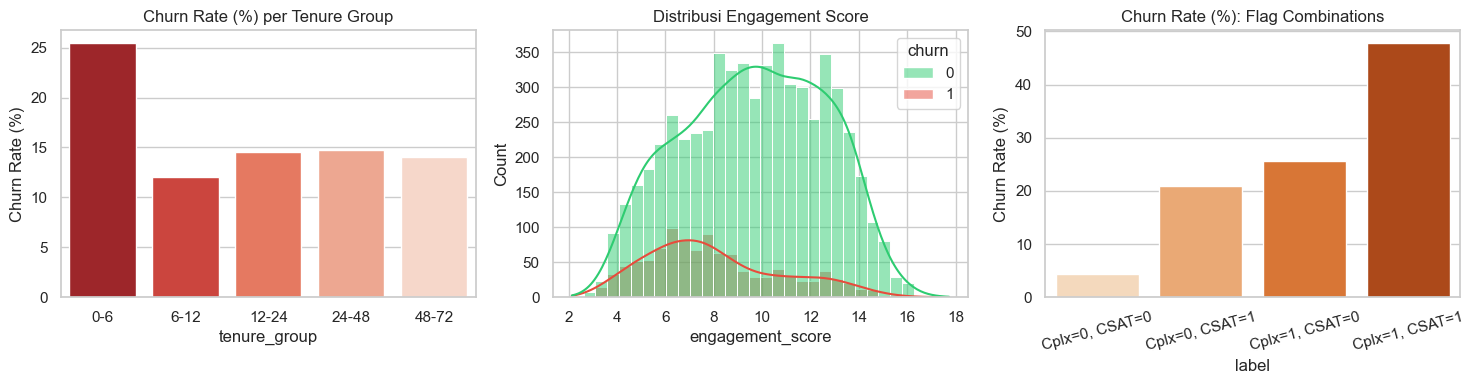

-> tenure_group menunjukkan pola monotonik turun (semakin lama tenure,
   semakin rendah churn). engagement_score memisahkan kedua kelas dengan jelas.
   Kombinasi flag (Cplx=1, CSAT=1) menghasilkan churn rate tertinggi -- valid!


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# tenure_group vs churn
tenure_churn = df_feat.groupby('tenure_group', observed=True)['churn'].mean() * 100
sns.barplot(x=tenure_churn.index, y=tenure_churn.values, ax=axes[0],
            hue=tenure_churn.index, legend=False, palette='Reds_r')
axes[0].set_title('Churn Rate (%) per Tenure Group')
axes[0].set_ylabel('Churn Rate (%)')

# engagement_score distribution
sns.histplot(data=df_feat, x='engagement_score', hue='churn', kde=True,
              ax=axes[1], palette={0: '#2ecc71', 1: '#e74c3c'}, alpha=0.5)
axes[1].set_title('Distribusi Engagement Score')

# high_complain_flag & low_csat_flag combined
flag_combo = df_feat.groupby(['high_complain_flag', 'low_csat_flag'])['churn'].mean() * 100
flag_combo = flag_combo.reset_index()
flag_combo['label'] = flag_combo.apply(
    lambda r: f"Cplx={int(r['high_complain_flag'])}, CSAT={int(r['low_csat_flag'])}", axis=1)
sns.barplot(x='label', y='churn', data=flag_combo, ax=axes[2],
            hue='label', legend=False, palette='Oranges')
axes[2].set_title('Churn Rate (%): Flag Combinations')
axes[2].set_ylabel('Churn Rate (%)')
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

print("-> tenure_group menunjukkan pola monotonik turun (semakin lama tenure,")
print("   semakin rendah churn). engagement_score memisahkan kedua kelas dengan jelas.")
print("   Kombinasi flag (Cplx=1, CSAT=1) menghasilkan churn rate tertinggi -- valid!")


## 2. Encoding Variabel Kategorikal

* Menggunakan `LabelEncoder` per kolom kategorikal. 
* Encoder disimpan sebagai `dict[nama_kolom -> LabelEncoder]` ke `models/encoder.pkl`

Kolom kategorikal (9 kolom):


In [4]:
print(CATEGORICAL_COLS)
print(f"\nTotal: {len(CATEGORICAL_COLS)} kolom")

# Cek jumlah kelas unik per kolom
for col in CATEGORICAL_COLS:
    print(f"  {col:25s}: {df_feat[col].nunique()} kelas -> {sorted(df_feat[col].astype(str).unique())}")


['gender', 'kota', 'paket', 'jenis_jaringan', 'metode_bayar', 'punya_streaming_bundle', 'punya_ewallet_linked', 'pernah_upgrade_paket', 'tenure_group']

Total: 9 kolom
  gender                   : 2 kelas -> ['Female', 'Male']
  kota                     : 8 kelas -> ['Bandung', 'Jakarta', 'Lainnya', 'Makassar', 'Medan', 'Semarang', 'Surabaya', 'Yogyakarta']
  paket                    : 3 kelas -> ['Hybrid', 'Pascabayar', 'Prabayar']
  jenis_jaringan           : 3 kelas -> ['4G', '5G', 'Fiber']
  metode_bayar             : 4 kelas -> ['Auto-debit', 'E-Wallet', 'Kartu Kredit', 'Transfer Bank']
  punya_streaming_bundle   : 2 kelas -> ['No', 'Yes']
  punya_ewallet_linked     : 2 kelas -> ['No', 'Yes']
  pernah_upgrade_paket     : 2 kelas -> ['No', 'Yes']
  tenure_group             : 5 kelas -> ['0-6', '12-24', '24-48', '48-72', '6-12']


In [5]:
encoders = fit_encoders(df_feat)
df_encoded = apply_encoders(df_feat, encoders)

print("Sebelum encoding:")
print(df_feat[['paket', 'jenis_jaringan', 'tenure_group']].head(5))
print("\nSetelah encoding:")
print(df_encoded[['paket', 'jenis_jaringan', 'tenure_group']].head(5))

print("\nMapping contoh untuk kolom 'paket':")
for cls, code in zip(encoders['paket'].classes_, range(len(encoders['paket'].classes_))):
    print(f"  '{cls}' -> {code}")


[2026-06-29 01:50:05] INFO | src.feature_engineering | Encoder fit untuk kolom 'gender': 2 kelas -> ['Female', 'Male']
[2026-06-29 01:50:05] INFO | src.feature_engineering | Encoder fit untuk kolom 'kota': 8 kelas -> ['Bandung', 'Jakarta', 'Lainnya', 'Makassar', 'Medan', 'Semarang', 'Surabaya', 'Yogyakarta']
[2026-06-29 01:50:05] INFO | src.feature_engineering | Encoder fit untuk kolom 'paket': 3 kelas -> ['Hybrid', 'Pascabayar', 'Prabayar']
[2026-06-29 01:50:05] INFO | src.feature_engineering | Encoder fit untuk kolom 'jenis_jaringan': 3 kelas -> ['4G', '5G', 'Fiber']
[2026-06-29 01:50:05] INFO | src.feature_engineering | Encoder fit untuk kolom 'metode_bayar': 4 kelas -> ['Auto-debit', 'E-Wallet', 'Kartu Kredit', 'Transfer Bank']
[2026-06-29 01:50:05] INFO | src.feature_engineering | Encoder fit untuk kolom 'punya_streaming_bundle': 2 kelas -> ['No', 'Yes']
[2026-06-29 01:50:05] INFO | src.feature_engineering | Encoder fit untuk kolom 'punya_ewallet_linked': 2 kelas -> ['No', 'Yes']


Sebelum encoding:
        paket jenis_jaringan tenure_group
0    Prabayar             5G        12-24
1      Hybrid             5G        24-48
2    Prabayar          Fiber        48-72
3  Pascabayar          Fiber        48-72
4    Prabayar             4G        12-24

Setelah encoding:
   paket  jenis_jaringan  tenure_group
0      2               1             1
1      0               1             2
2      2               2             3
3      1               2             3
4      2               0             1

Mapping contoh untuk kolom 'paket':
  'Hybrid' -> 0
  'Pascabayar' -> 1
  'Prabayar' -> 2


## 3. Scaling Variabel Numerik

`StandardScaler` (mean=0, std=1) diterapkan pada 7 kolom numerik

Kolom numerik yang di-scale:


In [6]:
print(NUMERIC_COLS_TO_SCALE)

scaler = fit_scaler(df_encoded)
df_scaled = apply_scaler(df_encoded, scaler)

print("\nSebelum scaling:")
print(df_encoded[NUMERIC_COLS_TO_SCALE].describe().loc[['mean', 'std']].round(2))
print("\nSetelah scaling (mean harus ~0, std ~1):")
print(df_scaled[NUMERIC_COLS_TO_SCALE].describe().loc[['mean', 'std']].round(2))


[2026-06-29 01:50:06] INFO | src.feature_engineering | Scaler fit pada 7 kolom numerik: ['usia', 'tenure_bulan', 'biaya_bulanan', 'total_pemakaian_data_gb', 'frekuensi_login_app', 'engagement_score', 'usage_per_cost']


['usia', 'tenure_bulan', 'biaya_bulanan', 'total_pemakaian_data_gb', 'frekuensi_login_app', 'engagement_score', 'usage_per_cost']

Sebelum scaling:
       usia  tenure_bulan  biaya_bulanan  total_pemakaian_data_gb  \
mean  40.89         36.06         148.91                    15.05   
std   13.45         20.93          64.38                    15.14   

      frekuensi_login_app  engagement_score  usage_per_cost  
mean                 8.03              9.39            0.12  
std                  2.80              2.99            0.16  

Setelah scaling (mean harus ~0, std ~1):
      usia  tenure_bulan  biaya_bulanan  total_pemakaian_data_gb  \
mean   0.0           0.0           -0.0                      0.0   
std    1.0           1.0            1.0                      1.0   

      frekuensi_login_app  engagement_score  usage_per_cost  
mean                  0.0              -0.0             0.0  
std                   1.0               1.0             1.0  


## 4. Pipeline End-to-End


In [7]:
# Jalankan pipeline lengkap dari awal (fresh) untuk verifikasi konsistensi
df_final, encoders_final, scaler_final = build_features_pipeline(df_clean, fit=True)

print(f"Shape final: {df_final.shape}")
print(f"\nKolom final ({len(df_final.columns)}):")
for col in df_final.columns:
    print(f"  - {col} ({df_final[col].dtype})")


[2026-06-29 01:50:08] INFO | src.feature_engineering | Feature creation selesai. Kolom baru: tenure_group, usage_per_cost, high_complain_flag, low_csat_flag, engagement_score
[2026-06-29 01:50:08] INFO | src.feature_engineering | Encoder fit untuk kolom 'gender': 2 kelas -> ['Female', 'Male']
[2026-06-29 01:50:08] INFO | src.feature_engineering | Encoder fit untuk kolom 'kota': 8 kelas -> ['Bandung', 'Jakarta', 'Lainnya', 'Makassar', 'Medan', 'Semarang', 'Surabaya', 'Yogyakarta']
[2026-06-29 01:50:08] INFO | src.feature_engineering | Encoder fit untuk kolom 'paket': 3 kelas -> ['Hybrid', 'Pascabayar', 'Prabayar']
[2026-06-29 01:50:08] INFO | src.feature_engineering | Encoder fit untuk kolom 'jenis_jaringan': 3 kelas -> ['4G', '5G', 'Fiber']
[2026-06-29 01:50:08] INFO | src.feature_engineering | Encoder fit untuk kolom 'metode_bayar': 4 kelas -> ['Auto-debit', 'E-Wallet', 'Kartu Kredit', 'Transfer Bank']
[2026-06-29 01:50:08] INFO | src.feature_engineering | Encoder fit untuk kolom 'pun

Shape final: (7000, 24)

Kolom final (24):
  - customer_id (object)
  - gender (int64)
  - usia (float64)
  - kota (int64)
  - tenure_bulan (float64)
  - paket (int64)
  - jenis_jaringan (int64)
  - kuota_gb (int64)
  - biaya_bulanan (float64)
  - punya_streaming_bundle (int64)
  - punya_ewallet_linked (int64)
  - metode_bayar (int64)
  - jumlah_komplain_6bln (int64)
  - skor_kepuasan_csat (int64)
  - pernah_upgrade_paket (int64)
  - total_pemakaian_data_gb (float64)
  - frekuensi_login_app (float64)
  - churn (int64)
  - is_unlimited (int64)
  - tenure_group (int64)
  - usage_per_cost (float64)
  - high_complain_flag (int64)
  - low_csat_flag (int64)
  - engagement_score (float64)


## 5. Cek: Tidak Ada Missing Values & Semua Numerik


In [8]:
print(f"Total missing values: {df_final.isna().sum().sum()}")

non_numeric = df_final.drop(columns=['customer_id']).select_dtypes(exclude=[np.number]).columns.tolist()
print(f"Kolom non-numerik (selain customer_id): {non_numeric}")

if len(non_numeric) == 0 and df_final.isna().sum().sum() == 0:
    print("\n[OK] Dataset siap untuk modeling!")
else:
    print("\n[WARNING] Masih ada isu yang perlu diperbaiki.")


Total missing values: 0
Kolom non-numerik (selain customer_id): []

[OK] Dataset siap untuk modeling!


## 6. Simpan Dataset Final & Artifacts

- `data/processed/telco_features.csv` — dataset siap modeling.
- `models/encoder.pkl` — dict LabelEncoder per kolom kategorikal.
- `models/scaler.pkl` — StandardScaler untuk kolom numerik.


In [9]:
df_final.to_csv(FEATURES_DATA_PATH, index=False)
save_pickle(encoders_final, ENCODER_PATH)
save_pickle(scaler_final, SCALER_PATH)

print(f"Dataset final disimpan ke : {FEATURES_DATA_PATH}")
print(f"Encoders disimpan ke       : {ENCODER_PATH}")
print(f"Scaler disimpan ke         : {SCALER_PATH}")
print(f"\nShape final: {df_final.shape}")


Dataset final disimpan ke : C:\Users\ACER\Downloads\telco-churn-2026\telco-churn-2026\data\processed\telco_features.csv
Encoders disimpan ke       : C:\Users\ACER\Downloads\telco-churn-2026\telco-churn-2026\models\encoder.pkl
Scaler disimpan ke         : C:\Users\ACER\Downloads\telco-churn-2026\telco-churn-2026\models\scaler.pkl

Shape final: (7000, 24)


## Ringkasan & Next Steps

* Feature creation: dibuat 5 fitur baru, yaitu tenure_group, usage_per_cost, high_complain_flag, low_csat_flag, dan engagement_score.
* Encoding: 9 kolom kategorikal diubah menjadi numerik menggunakan LabelEncoder, lalu hasilnya disimpan di encoder.pkl.
* Scaling: 7 kolom numerik dinormalisasi menggunakan StandardScaler, lalu hasilnya disimpan di scaler.pkl.
* Dataset final: file telco_features.csv berisi 24 kolom, 7000 baris, dan 0 missing values.
